In [2]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
df=pd.read_json('/content/drive/MyDrive/Magazine_Subscriptions.jsonl', lines=True)

In [4]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Great pictures and recipes,Wonderful recipes in this magazine.,[],B00HLSSQKK,B00HLSSQKK,AE7Y5RLYIKHOZB5NKKOEKYG2SPSQ,2020-12-15 15:29:02.433,0,True
1,4,great for kids who love sports!,Great sports magazine that's on my 9 year olds...,[],B002PXW04Y,B002PXW04Y,AHORTSSMI6ZZFUFWMPT4UFR2ISUQ,2016-08-12 03:28:32.000,1,True
2,5,A great look at what's new on the kosher scene...,"""Joy of Kosher"" magazine fills a much-needed n...",[],B00HCR5090,B00HCR5090,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2014-04-06 23:32:53.000,4,False
3,5,"If you enjoy reading an eye-catching, easy-to-...",I've been addicted to Martha Stewart's Everyda...,[],B0000ARXXS,B0000ARXXS,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2007-06-15 04:04:15.000,4,False
4,1,Too many “ gear ads” !!,Too many ads!,[],B0025ZOVEO,B0025ZOVEO,AFUB7CHTXRPD447QVQCHBZVN2IPQ,2020-06-01 21:24:40.246,13,True


In [5]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [6]:
columns_to_drop=['images', 'asin', 'parent_asin', 'user_id',
       'timestamp']
df.drop(columns=columns_to_drop, inplace=True)

In [7]:
df.head()

,rating,title,text,helpful_vote,verified_purchase
0,5,Great pictures and recipes,Wonderful recipes in this magazine.,0,True
1,4,great for kids who love sports!,Great sports magazine that's on my 9 year olds...,1,True
2,5,A great look at what's new on the kosher scene...,"""Joy of Kosher"" magazine fills a much-needed n...",4,False
3,5,"If you enjoy reading an eye-catching, easy-to-...",I've been addicted to Martha Stewart's Everyda...,4,False
4,1,Too many “ gear ads” !!,Too many ads!,13,True


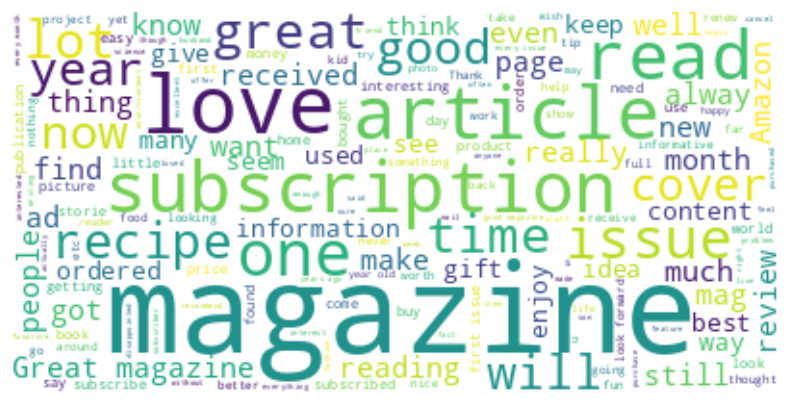

In [9]:


!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = " ".join(review for review in df.text)

# Create stopword list:
stopwords = set(STOPWORDS)
stopwords.update(["br", "text"]) # Add custom stopwords if any

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

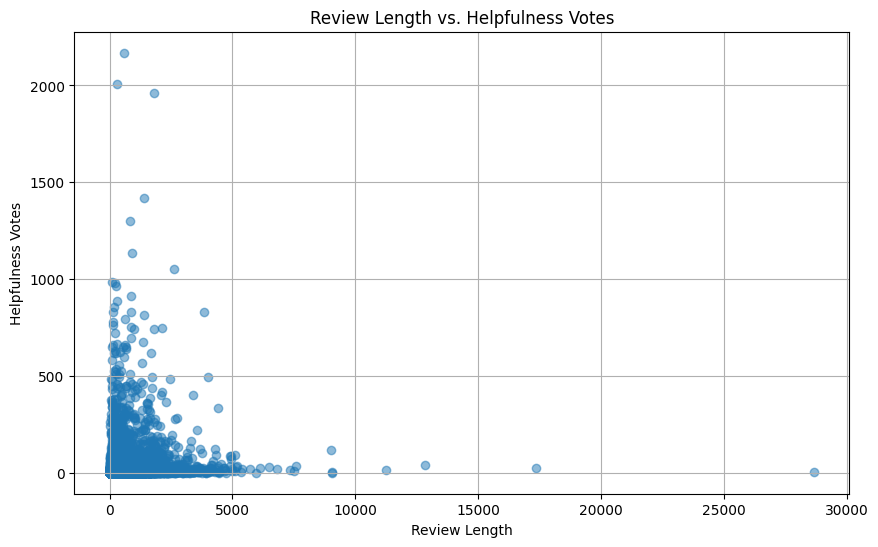

In [10]:


import matplotlib.pyplot as plt
df['review_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
plt.scatter(df['review_length'], df['helpful_vote'], alpha=0.5)
plt.xlabel('Review Length')
plt.ylabel('Helpfulness Votes')
plt.title('Review Length vs. Helpfulness Votes')
plt.grid(True)
plt.show()

In [29]:


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['helpful_vote'] = scaler.fit_transform(df[['helpful_vote']])

df.head()

,rating,title,text,helpful_vote,verified_purchase
0,5,Great pictures and recipes,Wonderful recipes in this magazine.,0.000000,True
1,4,great for kids who love sports!,Great sports magazine that's on my 9 year olds...,0.000461,True
2,5,A great look at what's new on the kosher scene...,"""Joy of Kosher"" magazine fills a much-needed n...",0.001844,False
3,5,"If you enjoy reading an eye-catching, easy-to-...",I've been addicted to Martha Stewart's Everyda...,0.001844,False
4,1,Too many “ gear ads” !!,Too many ads!,0.005994,True


In [30]:
df.columns

Index(['rating', 'title', 'text', 'helpful_vote', 'verified_purchase'], dtype='object')

In [31]:
df.shape

(71497, 5)

In [32]:
df.isnull().sum()

,0
rating,0
title,0
text,0
helpful_vote,0
verified_purchase,0


In [33]:
df["text"] = df["title"].fillna("")  + df["text"].fillna("")

In [34]:
!pip install textstat


In [35]:
import textstat

def extract_handcrafted_features(df):
    features = []
    for row in df.itertuples():
        text = row.text
        rating = row.rating
        verified = int(row.verified_purchase)


        length = len(text.split())
        readability = textstat.flesch_reading_ease(text)
        punctuation = text.count("!") + text.count("?")

        features.append([length, readability, rating / 5.0, verified, punctuation])
    return np.array(features)

X_handcrafted = extract_handcrafted_features(df)

In [36]:
X_handcrafted[1]

array([15.    , 92.0625,  0.8   ,  1.    ,  2.    ])

In [37]:


X_handcrafted.shape

(71497, 5)

In [16]:
pip install tensorflow transformers textstat pandas scikit-learn


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (853 > 512). Running this sequence through the model will result in indexing errors


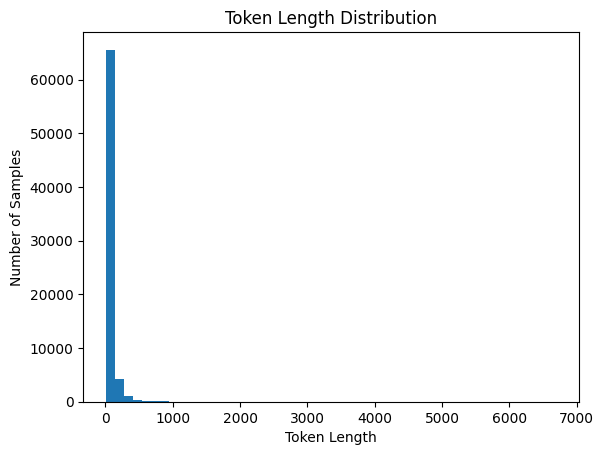

In [17]:
from transformers import BertTokenizer
import matplotlib.pyplot as plt

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
token_lens = [len(tokenizer.encode(t, truncation=False)) for t in df["text"]]

plt.hist(token_lens, bins=50)
plt.xlabel("Token Length")
plt.ylabel("Number of Samples")
plt.title("Token Length Distribution")
plt.show()

In [19]:


max_token_len = max(token_lens)
print(f"Maximum token length: {max_token_len}")

Maximum token length: 6704


In [19]:


# Calculate the number of texts with token length less than 128
count_less_than_128 = sum(1 for length in token_lens if length < 128)

# Calculate the total number of texts
total_texts = len(token_lens)

# Calculate the percentage
percentage_less_than_128 = (count_less_than_128 / total_texts) * 100

print(f"Percentage of texts with token length less than 128: {percentage_less_than_128:.2f}%")

Percentage of texts with token length less than 128: 90.61%


In [24]:
from transformers import PegasusTokenizer
tokenizer = PegasusTokenizer.from_pretrained("google/pegasus-xsum")

def summarize_if_needed(text, max_bert_tokens=128, summary_max_len=100, summary_min_len=30):
    token_count = len(tokenizer.encode(text, truncation=False))

    if token_count <= max_bert_tokens:
        return text  # no summarization needed

    try:
        summary = summarizer(
            text,
            max_length=summary_max_len,
            min_length=summary_min_len,
            do_sample=False
        )[0]['summary_text']
        return summary
    except Exception as e:
        print("Error during summarization:", e)
        return text  # fallback


In [ ]:
from tqdm import tqdm

df["summarized_text"] = [summarize_if_needed(t) for t in tqdm(df["text"])]


  0%|          | 0/71497 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (748 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (748 > 512). Running this sequence through the model will result in indexing errors

  0%|          | 3/71497 [00:00<4:58:36,  3.99it/s]

Error during summarization: index out of range in self


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.58.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.

  0%|          | 48/71497 [02:33<45:24:00,  2.29s/it]

Error during summarization: index out of range in self



  0%|          | 53/71497 [03:46<146:36:42,  7.39s/it]

...


  3%|▎         | 1870/71497 [1:00:49<27:08:46,  1.40s/it]

Error during summarization: index out of range in self



  3%|▎         | 2225/71497 [1:08:19<22:03:59,  1.15s/it]

Error during summarization: index out of range in self



  3%|▎         | 2274/71497 [1:08:34<12:24:36,  1.55it/s]

In [38]:
df.head()

,rating,title,text,helpful_vote,verified_purchase
0,5,Great pictures and recipes,Great pictures and recipesWonderful recipes in...,0.000000,True
1,4,great for kids who love sports!,great for kids who love sports!Great sports ma...,0.000461,True
2,5,A great look at what's new on the kosher scene...,A great look at what's new on the kosher scene...,0.001844,False
3,5,"If you enjoy reading an eye-catching, easy-to-...","If you enjoy reading an eye-catching, easy-to-...",0.001844,False
4,1,Too many “ gear ads” !!,Too many “ gear ads” !!Too many ads!,0.005994,True


In [26]:


summarized_token_lens = [len(tokenizer.encode(t, truncation=False)) for t in df["summarized_text"]]
max_summarized_token_len = max(summarized_token_lens)
print(f"Maximum token length of summarized texts: {max_summarized_token_len}")

Maximum token length of summarized texts: 6338


In [20]:
df.head()

,rating,title,text,helpful_vote,verified_purchase
0,5,Great pictures and recipes,Great pictures and recipesWonderful recipes in...,0.000000,True
1,4,great for kids who love sports!,great for kids who love sports!Great sports ma...,0.000461,True
2,5,A great look at what's new on the kosher scene...,A great look at what's new on the kosher scene...,0.001844,False
3,5,"If you enjoy reading an eye-catching, easy-to-...","If you enjoy reading an eye-catching, easy-to-...",0.001844,False
4,1,Too many “ gear ads” !!,Too many “ gear ads” !!Too many ads!,0.005994,True


In [39]:


df = df.head(10000).copy()

In [40]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_texts(texts, max_len=128):
    tokens = tokenizer(
        texts.tolist(),
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="tf"
    )
    return tokens["input_ids"], tokens["attention_mask"]

input_ids, attention_mask = tokenize_texts(df["text"])


In [42]:
attention_mask

<tf.Tensor: shape=(10000, 128), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int32)>

In [48]:
from sklearn.model_selection import train_test_split

y = df["helpful_vote"].values

X_train = {
    "input_ids": input_ids[:int(0.9*len(df))],
    "attention_mask": attention_mask[:int(0.9*len(df))],
    "handcrafted_feats": X_handcrafted[:int(0.9*len(df))]
}
y_train = y[:int(0.9*len(df))]

X_val = {
    "input_ids": input_ids[int(0.9*len(df)):],
    "attention_mask": attention_mask[int(0.9*len(df)):],
    "handcrafted_feats": X_handcrafted[int(0.9*len(df)):]
}
y_val = y[int(0.9*len(df)):]


In [45]:
import tensorflow as tf
from transformers import TFBertModel

def build_model(handcrafted_dim, lstm_units=128, dense_units=128):
    # Inputs
    input_ids = tf.keras.Input(shape=(128,), dtype=tf.int32, name="input_ids")
    attention_mask = tf.keras.Input(shape=(128,), dtype=tf.int32, name="attention_mask")
    handcrafted_input = tf.keras.Input(shape=(handcrafted_dim,), name="handcrafted_feats")

    # BERT
    bert = TFBertModel.from_pretrained("bert-base-uncased")
    bert_output = bert(input_ids, attention_mask=attention_mask).last_hidden_state  # (batch, seq, 768)

    # Bi-GRU
    x = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(lstm_units))(bert_output)  # (batch, 2*lstm_units)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)  # (batch, dense_units)

    # Handcrafted Features
    h = tf.keras.layers.Dense(dense_units, activation="relu")(handcrafted_input)


    combined = tf.keras.layers.Concatenate(axis=1)([x, h])  # (batch, 2*dense_units)
    expanded = tf.expand_dims(combined, 1)  # Add time dimension: (batch, 1, 2*dense_units)

    # Self-Attention
    attended = tf.keras.layers.Attention(use_scale=True)([expanded, expanded])
    pooled = tf.keras.layers.GlobalAveragePooling1D()(attended)

    # Final prediction
    output = tf.keras.layers.Dense(1, activation="sigmoid")(pooled)

    model = tf.keras.Model(inputs=[input_ids, attention_mask, handcrafted_input], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="mse", metrics=["mae"])

    return model


In [46]:


X_handcrafted = X_handcrafted[:10000]

In [49]:
model = build_model(handcrafted_dim=X_handcrafted.shape[1])
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=16, epochs=3)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/3


563/563 [==============================] - 302s 454ms/step - loss: 4.2029e-04 - mae: 0.0033 - val_loss: 1.4713e-04 - val_mae: 0.0026
Epoch 2/3
563/563 [==============================] - 253s 449ms/step - loss: 3.3774e-04 - mae: 0.0026 - val_loss: 1.4636e-04 - val_mae: 0.0025
Epoch 3/3
563/563 [==============================] - 252s 447ms/step - loss: 3.3711e-04 - mae: 0.0025 - val_loss: 1.4619e-04 - val_mae: 0.0025


In [50]:
def predict_helpfulness(text, handcrafted_feat):
    tokens = tokenizer(text, return_tensors="tf", padding="max_length", truncation=True, max_length=128)
    inputs = {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
        "handcrafted_feats": tf.convert_to_tensor([handcrafted_feat])
    }
    pred = model.predict(inputs)
    return float(pred[0][0])


In [51]:
sample_text = "Very expensive and badly presented magazine."
sample_features = [6, 75.0, 0.8, 1, 2]  # length, readability, rating/5, verified, punctuation
print("Predicted Helpfulness Score:", predict_helpfulness(sample_text, sample_features))


1/1 [==============================] - 4s 4s/step
Predicted Helpfulness Score: 9.765666391103878e-07
